In [ ]:
path: "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devnagari digit.zip"

In [ ]:
pip install keras tensorflow

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


##Manual Gradient Calculation in Numpy

In [ ]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
  return x ** 2
# Manual derivative (f’(x) = 2x)
def gradient(x):
  return 2 * x
# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
  x -= learning_rate * gradient(x)
  print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


##Gradient Computations with Keras.

In [ ]:
x = tf.Variable(5.0)
with tf.GradientTape() as tape:
  y = x ** 2
grad = tape.gradient(y,x)
print(grad.numpy())

10.0


##Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

In [ ]:
import time
import numpy as np
import tensorflow as tf

size = (1000,1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A,B)
print("Numpy Time: ", time.time()-start)

A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf,B_tf)
print("Tensorflow Time: ", time.time()-start)

Numpy Time:  0.08180069923400879
Tensorflow Time:  0.17084097862243652


##Implementation of Activation Function with Keras.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

##Manually Training Network in Numpy.

In [ ]:
import numpy as np

# Sample data for demonstration (replace with actual data)
x_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]) # Input features
y_train = np.array([[0], [1], [1], [0]])             # Target labels (e.g., XOR problem)
weights = np.random.rand(x_train.shape[1], y_train.shape[1]) # Initial random weights
learning_rate = 0.1 # Define learning_rate as it's used in the loop

for epoch in range(10):
  y_pred = np.dot(x_train, weights)
  loss = np.mean((y_pred-y_train)**2)
  gradients = 2 * np.dot(x_train.T, y_pred-y_train) / len(x_train)
  weights -= learning_rate*gradients
  print(f"Epoch {epoch+1}, Loss: {loss}")

Epoch 1, Loss: 0.46479461536401057
Epoch 2, Loss: 0.42831753223291513
Epoch 3, Loss: 0.40196250596403804
Epoch 4, Loss: 0.38292069831451303
Epoch 5, Loss: 0.3691627204815703
Epoch 6, Loss: 0.3592223361922091
Epoch 7, Loss: 0.3520401871553289
Epoch 8, Loss: 0.3468508846736782
Epoch 9, Loss: 0.3431014333089253
Epoch 10, Loss: 0.3403922919575024


##keras training is One Line.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define a simple Sequential model
model = Sequential([
    Dense(1, activation='sigmoid', input_shape=(x_train.shape[1],))
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Now, fit the model
model.fit(x_train, y_train, epochs=10, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.8507
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2500 - loss: 0.8502
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2500 - loss: 0.8497
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2500 - loss: 0.8492
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2500 - loss: 0.8487
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2500 - loss: 0.8482
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2500 - loss: 0.8477
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2500 - loss: 0.8472
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2500 - loss: 0.8468
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2500 - loss: 0.8463


##Layers in Keras.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
Dense(64, activation='relu', input_shape=(784,)),
Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Implementing SGD in Numpy.

In [ ]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

##In Keras.

In [ ]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

##Suntax of Dense Layer.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(32, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

In [ ]:
import zipfile
import os

zip_file_path = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devnagari digit.zip"  # Directly assign the path string
extract_dir = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}' successfully.")

'/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devnagari digit.zip' extracted to '/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/' successfully.


##Loading and Preprocessing Data with PIL.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


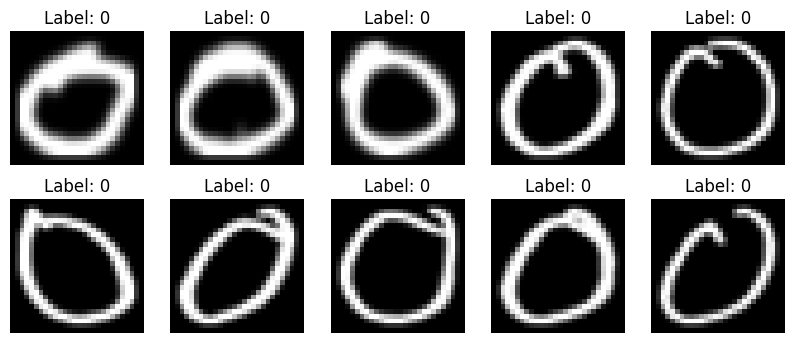

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

In [2]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

##Build the Model

In [17]:
from tensorflow import keras

model = keras.Sequential([
    keras.Input(shape=(784,)), # Using Input layer instead of input_shape
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

##Compile the Model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if val_loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Define ModelCheckpoint callback to save the best model
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/best_devanagari_model.keras', # Path to save the best model
    monitor='val_loss',        # Monitor validation loss
    save_best_only=True,       # Save only the best model
    verbose=1
)

##Train the model


In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=200, # Increased epochs to 200
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint] # Added callbacks
)

Epoch 1/200
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2248 - loss: 2.0539
Epoch 1: val_loss improved from None to 6.56193, saving model to /content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/best_devanagari_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/best_devanagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4200 - loss: 1.6914 - val_accuracy: 0.0000e+00 - val_loss: 6.5619
Epoch 2/200
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7798 - loss: 0.7396
Epoch 2: val_loss did not improve from 6.56193
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8099 - loss: 0.5769 - val_accuracy: 0.0000e+00 - val_loss: 7.6933
Epoch 3/200
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8784 - loss: 0.3473
Epoch 3: val_loss did not improve from 6.56193
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8939 - loss: 0.3134 - val_accuracy: 0.0000e+00 - val_loss: 8.4697
Epoch 4/200

##Evaluate the Model

In [22]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6110 - loss: 2.0795
Test Accuracy: 0.6110000014305115


##Save the Model

In [23]:
model.save("/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devanagari_model.h5")

In [24]:
model.save("/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devanagari_model.keras")

You can load this model back using `tf.keras.models.load_model('your_model.keras')`.

##Load the Model

In [25]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/Herald/6th Sem AI/Data/Workshop-4/devanagari_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [26]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0
Actual: 0


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted label for first image : 0
True label for first image      : 0


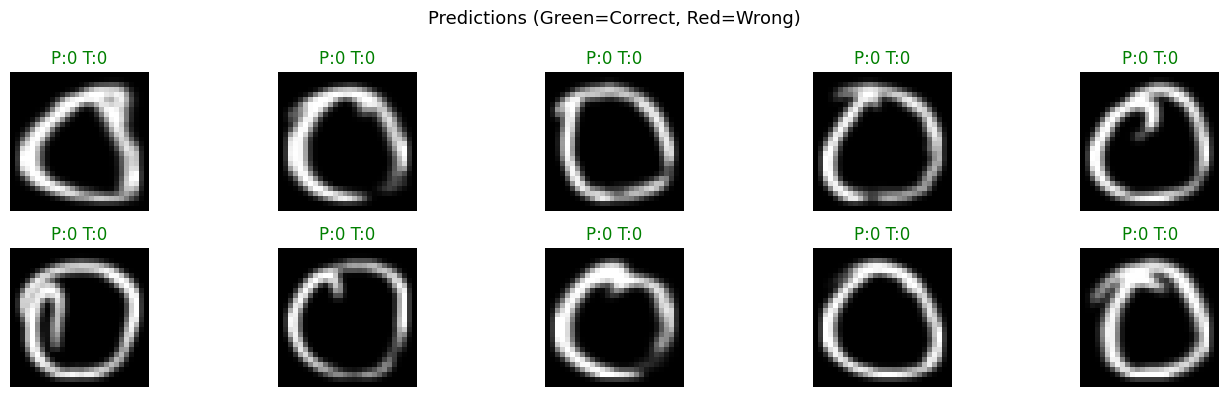

Prediction visualisation saved as predictions.png


In [27]:
# ─── Get predicted probabilities ───
predictions = loaded_model.predict(x_test)

# Convert probabilities → class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,  axis=1)

print(f"Predicted label for first image : {predicted_labels[0]}")
print(f"True label for first image      : {true_labels[0]}")

# ─── Visualise 10 predictions ───
plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(img_height, img_width), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"P:{predicted_labels[i]} T:{true_labels[i]}", color=color)
    plt.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()
print("Prediction visualisation saved as predictions.png")